# Fender Curve Mapping — Per-Fender Dynamic Max

For every combination of heading × HL line × Hs/Tp condition, find the dynamic max force
for each of the 6 fenders and plot where on the fender spring curve that maximum falls.

If `Deformation_FenderX` is stored in the HDF5, the (deformation, force) point is plotted directly.
Otherwise, the max force is intersected against the piecewise spring curve to find the deformation.

In [ ]:
import os, glob
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pathlib import Path

HEADINGS       = ['0deg', '45deg', '90deg', '135deg', '180deg']
HEADING_LABELS = {'0deg': '0°', '45deg': '45°', '90deg': '90°',
                  '135deg': '135°', '180deg': '180°'}
# Resolve this notebook's folder (works in VS Code and standard Jupyter)
NOTEBOOK_DIR   = Path(globals().get('__vsc_ipynb_file__', Path.cwd() / '_')).parent
os.chdir(NOTEBOOK_DIR)
import sys
sys.path.insert(0, str(NOTEBOOK_DIR))
from thesis_style import apply, full, save
apply()
print(f'Working directory: {Path.cwd()}')

# Fender spring curve (from SIMA input table)
CURVE_DIST_M   = np.array([0.0, -0.25, -0.5, -0.75, -0.95, -1.05, -1.25, -1.5,
                             -1.75, -1.95, -2.05, -2.25, -2.5])
CURVE_FORCE_KN = np.array([0.0, 818.18, 1242.4, 1393.9, 1272.0, 1272.0,
                             1620.5, 2000.0, 1930.3, 1808.3, 1808.3,
                             2822.7, 5053.0])
CURVE_DIST_POS = np.abs(CURVE_DIST_M)

FENDER_ELEMS   = [f'Fender{i}' for i in range(1, 7)]
FENDER_MARKERS = ['o', 's', '^', 'D', 'v', 'P']
FENDER_COLORS  = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00', '#a65628']


def find_curve_intersections(force_kN):
    """Return list of deformation values [m] where curve == force_kN."""
    pts = []
    for i in range(len(CURVE_FORCE_KN) - 1):
        f0, f1 = CURVE_FORCE_KN[i], CURVE_FORCE_KN[i + 1]
        d0, d1 = CURVE_DIST_M[i], CURVE_DIST_M[i + 1]
        if f0 == f1:
            continue
        flo, fhi = min(f0, f1), max(f0, f1)
        if flo <= force_kN <= fhi:
            t = (force_kN - f0) / (f1 - f0)
            pts.append(d0 + t * (d1 - d0))
    return pts

In [2]:
g         = 9.81
N_COND    = 10
HS_VALUES = np.linspace(0.5, 3.5, N_COND)
_B        = 'BerthedTanker_Catenary'

LINES = {
    'HL7':  {'n': 7,  'base': f'{_B}/Run1',
             'dynamic': 'HL7/DynamicResults_HL7_run1-1.h5',
             'color': '#1f77b4', 'label': '$H/\\lambda = 1/7$',  'n_cond': 9},
    'HL9':  {'n': 9,  'base': f'{_B}/Run2',
             'dynamic': 'HL9/DynamicResults_HL9_run2-1.h5',
             'color': '#ff7f0e', 'label': '$H/\\lambda = 1/9$',  'n_cond': 9},
    'HL11': {'n': 11, 'base': f'{_B}/Run3',
             'dynamic': 'HL11/DynamicResults_HL11_run3-1.h5',
             'color': '#2ca02c', 'label': '$H/\\lambda = 1/11$', 'n_cond': 9},
    'HL13': {'n': 13, 'base': f'{_B}/Run4',
             'dynamic': 'HL13/DynamicResults_HL13_run4-1.h5',
             'color': '#d62728', 'label': '$H/\\lambda = 1/13$', 'n_cond': 9},
    'HL15': {'n': 15, 'base': f'{_B}/Run5',
             'dynamic': 'HL15/DynamicResults_HL15_run5-1.h5',
             'color': '#9467bd', 'label': '$H/\\lambda = 1/15$', 'n_cond': 9},
    'HL17': {'n': 17, 'base': f'{_B}/Run6',
             'dynamic': 'HL17/DynamicResults_HL17_run6-1.h5',
             'color': '#8c564b', 'label': '$H/\\lambda = 1/17$', 'n_cond': 9},
    'HL19': {'n': 19, 'base': f'{_B}/Run7',
             'dynamic': 'HL19/DynamicResults_HL19_run7-1.h5',
             'color': '#e377c2', 'label': '$H/\\lambda = 1/19$', 'n_cond': 9},
    'HL21': {'n': 21, 'base': f'{_B}/Run8',
             'dynamic': 'HL21/DynamicResults_HL21_run8-1.h5',
             'color': '#7f7f7f', 'label': '$H/\\lambda = 1/21$', 'n_cond': 9},
    'HL23': {'n': 23, 'base': f'{_B}/Run9',
             'dynamic': 'HL23/DynamicResults_HL23_run9-1.h5',
             'color': '#bcbd22', 'label': '$H/\\lambda = 1/23$', 'n_cond': 9},
    'HL25': {'n': 25, 'base': f'{_B}/Run10',
             'dynamic': 'HL25/DynamicResults_HL25_run10-1.h5',
             'color': '#17becf', 'label': '$H/\\lambda = 1/25$', 'n_cond': 8},
    'HL27': {'n': 27, 'base': f'{_B}/Run11',
             'dynamic': 'HL27/DynamicResults_HL27_run11-1.h5',
             'color': '#aec7e8', 'label': '$H/\\lambda = 1/27$', 'n_cond': 7},
    'HL29': {'n': 29, 'base': f'{_B}/Run12',
             'dynamic': 'HL29/DynamicResults_HL29_run12-1.h5',
             'color': '#ffbb78', 'label': '$H/\\lambda = 1/29$', 'n_cond': 7},
}

for cfg in LINES.values():
    nc      = cfg['n_cond']
    Hs_vals = HS_VALUES[:nc]
    Tp_vals = np.sqrt(Hs_vals * 2 * np.pi * cfg['n'] / g)
    cfg['cond_params'] = {
        i + 1: (round(float(hs), 2), round(float(tp), 2))
        for i, (hs, tp) in enumerate(zip(Hs_vals, Tp_vals))
    }

In [3]:
# Explore HDF5 structure to see which fender datasets are stored
_sample = '0deg/HL7/DynamicResults_HL7_run1-1.h5'
print(f'Fender datasets in: {_sample}\n')
_found = []
with h5py.File(_sample, 'r') as _f:
    def _collect(name, obj):
        if 'Fender' in name and isinstance(obj, h5py.Dataset):
            _found.append(f'  {name}  shape={obj.shape}')
    _f.visititems(_collect)
print('\n'.join(_found[:60]))
if len(_found) > 60:
    print(f'  ... {len(_found) - 60} more')

Fender datasets in: 0deg/HL7/DynamicResults_HL7_run1-1.h5

  BerthedTanker_Catenary0deg/Run1/Run1_1/Dynamic/Tanker/Positioning system force/TotalForce_Fender1  shape=(21600,)
  BerthedTanker_Catenary0deg/Run1/Run1_1/Dynamic/Tanker/Positioning system force/TotalForce_Fender2  shape=(21600,)
  BerthedTanker_Catenary0deg/Run1/Run1_1/Dynamic/Tanker/Positioning system force/TotalForce_Fender3  shape=(21600,)
  BerthedTanker_Catenary0deg/Run1/Run1_1/Dynamic/Tanker/Positioning system force/TotalForce_Fender4  shape=(21600,)
  BerthedTanker_Catenary0deg/Run1/Run1_1/Dynamic/Tanker/Positioning system force/TotalForce_Fender5  shape=(21600,)
  BerthedTanker_Catenary0deg/Run1/Run1_1/Dynamic/Tanker/Positioning system force/TotalForce_Fender6  shape=(21600,)
  BerthedTanker_Catenary0deg/Run1/Run1_2/Dynamic/Tanker/Positioning system force/TotalForce_Fender1  shape=(21600,)
  BerthedTanker_Catenary0deg/Run1/Run1_2/Dynamic/Tanker/Positioning system force/TotalForce_Fender2  shape=(21600,)
  BerthedTank

In [4]:
rows = []

for heading in HEADINGS:
    print(f'\n=== {heading} ===')
    for line_name, cfg in LINES.items():
        dyn_base  = f'{heading}/{cfg["dynamic"]}'.rsplit('-', 1)[0]
        dyn_files = sorted(
            glob.glob(f'{dyn_base}-*.h5'),
            key=lambda p: int(p.rsplit('-', 1)[-1].replace('.h5', ''))
        )
        run_key = cfg['base'].split('/')[-1]

        if not dyn_files:
            print(f'  {line_name}: no files found')
            continue

        # {cond_num: {fender: list of (max_force_N, defm_at_max_m or nan)}}
        cond_data = {}

        for dyn_file in dyn_files:
            try:
                with h5py.File(dyn_file, 'r') as fd:
                    root   = list(fd.keys())[0]
                    base_d = f'{root}/{run_key}'
                    for cond_key in fd[base_d].keys():
                        n = int(cond_key.split('_')[-1])
                        if n > cfg['n_cond']:
                            continue
                        if n not in cond_data:
                            cond_data[n] = {fdr: [] for fdr in FENDER_ELEMS}
                        grp = fd[f'{base_d}/{cond_key}/Dynamic/Tanker/Positioning system force']
                        for fdr in FENDER_ELEMS:
                            force_ts = grp[f'TotalForce_{fdr}'][:]
                            idx      = int(np.argmax(force_ts))
                            f_max    = float(force_ts[idx])
                            defm_key = f'Deformation_{fdr}'
                            defm     = float(grp[defm_key][idx]) if defm_key in grp else np.nan
                            cond_data[n][fdr].append((f_max, defm))
            except FileNotFoundError:
                print(f'  WARNING: {dyn_file} not found')

        for n, fdr_data in sorted(cond_data.items()):
            hs, tp = cfg['cond_params'].get(n, (np.nan, np.nan))
            for i, fdr in enumerate(FENDER_ELEMS):
                seeds = fdr_data[fdr]
                if not seeds:
                    continue
                f_max_N, defm_m = max(seeds, key=lambda x: x[0])
                rows.append({
                    'heading':      heading,
                    'line':         line_name,
                    'cond_num':     n,
                    'Hs':           hs,
                    'Tp':           tp,
                    'fender':       fdr,
                    'fender_idx':   i,
                    'max_force_kN': f_max_N / 1e3,
                    'defm_m':       defm_m,
                })
        print(f'  {line_name}: OK')

df = pd.DataFrame(rows)
has_defm = df['defm_m'].notna().any()
print(f'\nTotal rows: {len(df)},  deformation data available: {has_defm}')
print(df.head(12).to_string())


=== 0deg ===


  HL7: OK


  HL9: OK


  HL11: OK


  HL13: OK


...

  HL21: OK


  HL23: OK


  HL25: OK


  HL27: OK


  HL29: OK

Total rows: 3090,  deformation data available: False
   heading line  cond_num    Hs    Tp   fender  fender_idx  max_force_kN  defm_m
0     0deg  HL7         1  0.50  1.50  Fender1           0    142.807037     NaN
1     0deg  HL7         1  0.50  1.50  Fender2           1    138.723526     NaN
2     0deg  HL7         1  0.50  1.50  Fender3           2    134.876419     NaN
3     0deg  HL7         1  0.50  1.50  Fender4           3    132.790665     NaN
4     0deg  HL7         1  0.50  1.50  Fender5           4    133.345627     NaN
5     0deg  HL7         1  0.50  1.50  Fender6           5    134.125198     NaN
6     0deg  HL7         2  0.83  1.93  Fender1           0    151.228027     NaN
7     0deg  HL7         2  0.83  1.93  Fender2           1    144.612686     NaN
8     0deg  HL7         2  0.83  1.93  Fender3           2    138.446732     NaN
9     0deg  HL7         2  0.83  1.93  Fender4           3    137.067413     NaN
10    0deg  HL7         2  0.83  1.93  Fende

## Fender Spring Curve — Dynamic Max per Heading

One figure per heading (5 total). Every steepness line and condition is overlaid on the fender
spring curve. To reduce clutter, only the **governing fender** (the one carrying the maximum force)
per steepness line + condition is shown; colour = $H_s$ (colourbar), marker shape = fender.

The tabulated curve ends at 2.5 m / 5053 kN — full compression, i.e. **fender bottoming**.
A larger max force means the fender has bottomed out: deformation is capped at 2.5 m and the
force rises, so these points (ringed in red) are plotted on a vertical line at 2.5 m. They mark a
limitation of the study — at those sea states the fenders are too weak and bottom out.

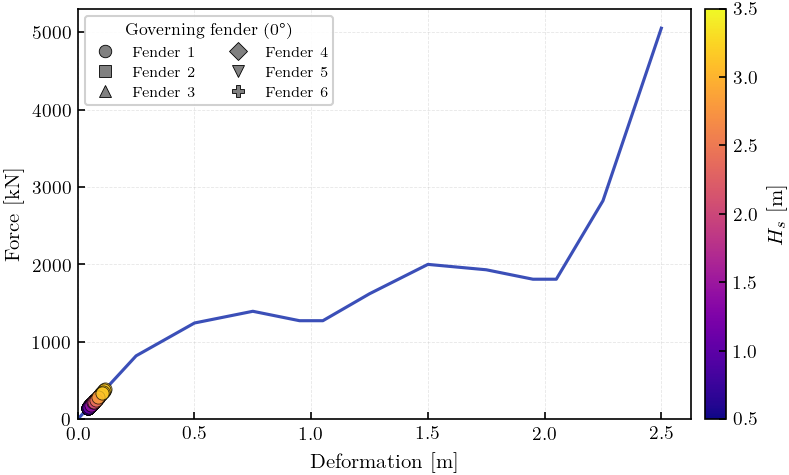

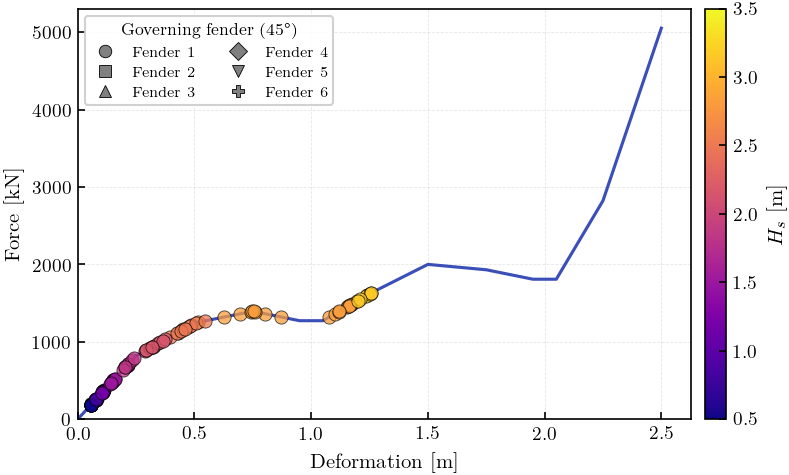

90deg: 12 bottomed point(s) above 5053 kN (max 13961 kN) — plotted vertically at 2.5 m


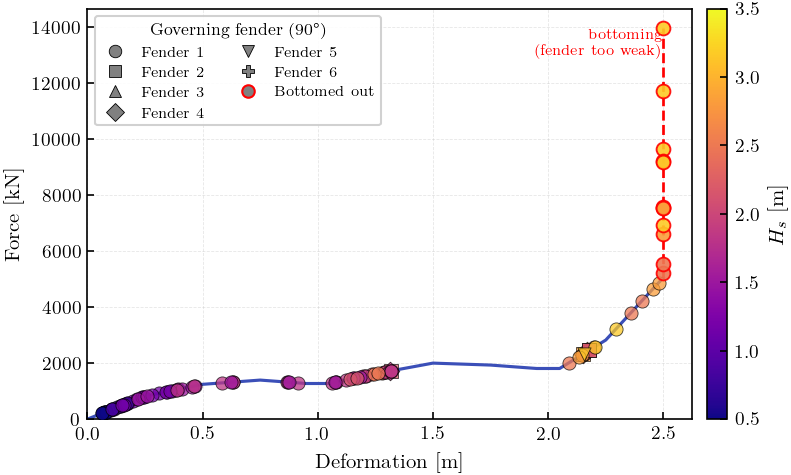

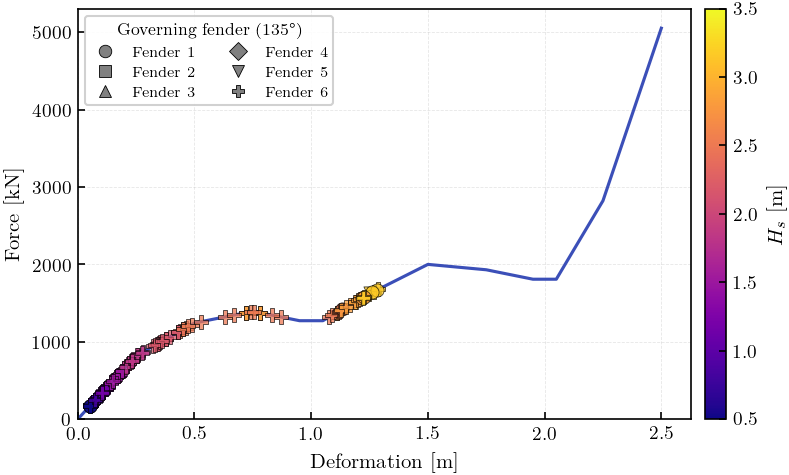

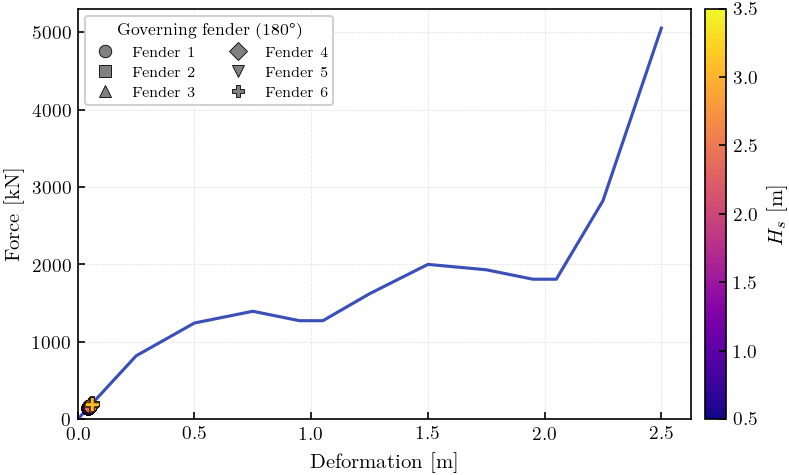

In [5]:
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

CMAP = plt.cm.plasma
norm = Normalize(vmin=0.5, vmax=3.5)

# Bottoming: tabulated curve ends at 2.5 m / 5053 kN (full compression). The fender cannot
# deflect further, so a larger max force is shown on a vertical line at 2.5 m — deformation is
# capped, force rises. These points flag a study limitation (fenders too weak, they bottom out).
F_MAX_CURVE = CURVE_FORCE_KN[-1]
D_BOTTOM    = CURVE_DIST_POS[-1]

fender_handles = [
    Line2D([0], [0], marker=FENDER_MARKERS[i], color='w',
           markerfacecolor='gray', markeredgecolor='k',
           markeredgewidth=0.4, markersize=6,
           label=f'Fender {i + 1}')
    for i in range(6)
]

# One figure per heading — all steepness lines and conditions overlaid, coloured by Hs (swell-style).
# Only the governing (max-force) fender per steepness line + condition is plotted, to reduce clutter.
for heading in HEADINGS:
    sub = df[df.heading == heading]
    if sub.empty:
        continue

    gov = sub.loc[sub.groupby(['line', 'cond_num'])['max_force_kN'].idxmax()]

    fig, ax = plt.subplots(figsize=full())
    ax.plot(CURVE_DIST_POS, CURVE_FORCE_KN, color='#3B4FB8', lw=1.5, zorder=2)

    n_bottom     = 0
    f_bottom_max = F_MAX_CURVE
    for _, row in gov.iterrows():
        f_kN  = row['max_force_kN']
        fi    = int(row['fender_idx'])
        defm  = row['defm_m']
        color = CMAP(norm(row['Hs']))

        if has_defm and not np.isnan(defm):
            ax.scatter(-defm, f_kN, color=color,
                       marker=FENDER_MARKERS[fi], s=40,
                       alpha=0.85, linewidths=0.4,
                       edgecolors='k', zorder=5)
        else:
            inter = find_curve_intersections(f_kN)
            if inter:
                for d_int in inter:
                    ax.scatter(-d_int, f_kN, color=color,
                               marker=FENDER_MARKERS[fi], s=40,
                               alpha=0.75, linewidths=0.4,
                               edgecolors='k', zorder=5)
            elif f_kN > F_MAX_CURVE:
                # fender bottomed out — deformation fixed at 2.5 m, plot straight up
                ax.scatter(D_BOTTOM, f_kN, color=color,
                           marker=FENDER_MARKERS[fi], s=44,
                           alpha=0.9, linewidths=0.9,
                           edgecolors='red', zorder=6)
                n_bottom    += 1
                f_bottom_max = max(f_bottom_max, f_kN)

    # vertical bottoming branch at 2.5 m: force rises, deformation can't grow
    if n_bottom:
        ax.plot([D_BOTTOM, D_BOTTOM], [F_MAX_CURVE, f_bottom_max],
                color='red', lw=1.3, ls='--', zorder=3)
        ax.text(D_BOTTOM, f_bottom_max, ' bottoming\n (fender too weak)',
                va='top', ha='right', fontsize=7, color='red')

    ax.set_xlabel('Deformation [m]', fontsize=10)
    ax.set_ylabel('Force [kN]', fontsize=10)
    ax.tick_params(labelsize=9)
    ax.set_xlim(left=0)
    ax.set_ylim(bottom=0)
    ax.grid(True, alpha=0.3)

    sm = ScalarMappable(norm=norm, cmap=CMAP)
    sm.set_array([])
    cb = fig.colorbar(sm, ax=ax, pad=0.02)
    cb.set_label('$H_s$ [m]')

    handles = list(fender_handles)
    if n_bottom:
        handles.append(Line2D([0], [0], marker='o', color='w',
                              markerfacecolor='gray', markeredgecolor='red',
                              markeredgewidth=1.0, markersize=6,
                              label='Bottomed out'))
    ax.legend(handles=handles, fontsize=7, ncol=2,
              loc='upper left', title=f'Governing fender  ({HEADING_LABELS[heading]})',
              title_fontsize=8, framealpha=0.9)

    if n_bottom:
        print(f'{heading}: {n_bottom} bottomed point(s) above {F_MAX_CURVE:.0f} kN '
              f'(max {f_bottom_max:.0f} kN) — plotted vertically at 2.5 m')

    plt.tight_layout()
    save(fig, f'fender_curve_{heading}')
    plt.show()

## Severe heading — mildest vs steepest steepness (separate figures)

Same fender-curve mapping as above, but isolated to the **most severe heading** (the one
with the most bottoming points) and split into two figures: the **mildest** line
$H/\lambda = 1/29$ (HL29) and the **steepest** line $H/\lambda = 1/7$ (HL7), each on its own
axes. Colour = $H_s$, marker = fender; bottomed points are ringed in red on the vertical
branch at 2.5 m.

Most severe heading: 90° (50 bottomed points)


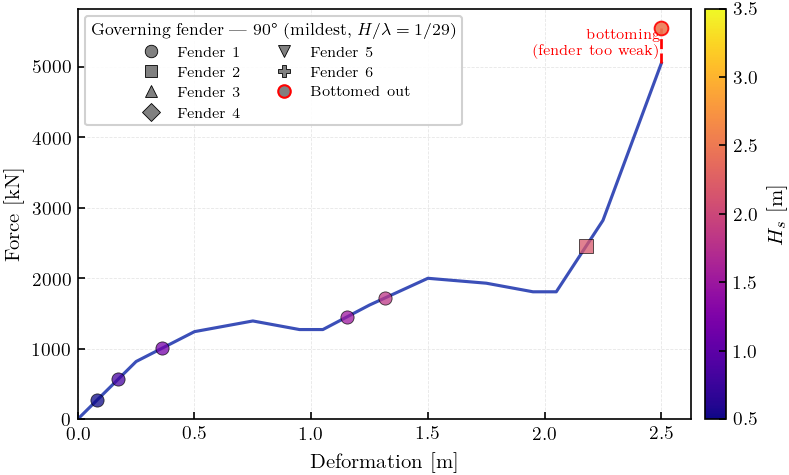

HL29 (mildest): 42 points, 1 bottomed -> fender_curve_90deg_HL29


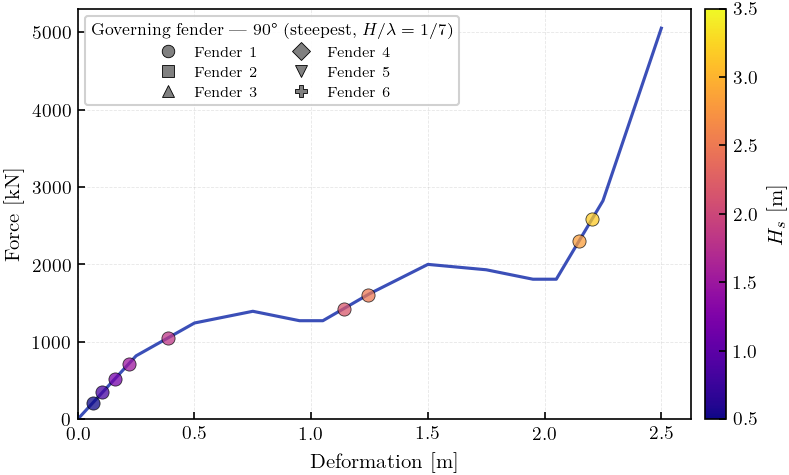

HL7 (steepest): 54 points, 0 bottomed -> fender_curve_90deg_HL7


In [6]:
# Most severe heading = where fender bottoming occurs (max force exceeds the curve end, 5053 kN).
# Falls back to the largest peak force if nothing bottoms out.
_bottom = df[df.max_force_kN > F_MAX_CURVE]
if not _bottom.empty:
    severe_heading = _bottom.groupby('heading').size().idxmax()
else:
    severe_heading = df.groupby('heading')['max_force_kN'].max().idxmax()
print(f'Most severe heading: {HEADING_LABELS[severe_heading]} '
      f'({len(_bottom[_bottom.heading == severe_heading])} bottomed points)')

# Mildest = HL29 (1/29), steepest = HL7 (1/7)
STEEP_LINES = {'HL29': 'mildest', 'HL7': 'steepest'}


def plot_fender_curve_single(sub, heading, line_name, descriptor):
    """One fender-curve figure for a single heading and single steepness line.
    Only the governing (max-force) fender per condition is plotted, to reduce clutter."""
    gov = sub.loc[sub.groupby('cond_num')['max_force_kN'].idxmax()]

    fig, ax = plt.subplots(figsize=full())
    ax.plot(CURVE_DIST_POS, CURVE_FORCE_KN, color='#3B4FB8', lw=1.5, zorder=2)

    n_bottom     = 0
    f_bottom_max = F_MAX_CURVE
    for _, row in gov.iterrows():
        f_kN  = row['max_force_kN']
        fi    = int(row['fender_idx'])
        defm  = row['defm_m']
        color = CMAP(norm(row['Hs']))

        if has_defm and not np.isnan(defm):
            ax.scatter(-defm, f_kN, color=color, marker=FENDER_MARKERS[fi], s=40,
                       alpha=0.85, linewidths=0.4, edgecolors='k', zorder=5)
        else:
            inter = find_curve_intersections(f_kN)
            if inter:
                for d_int in inter:
                    ax.scatter(-d_int, f_kN, color=color, marker=FENDER_MARKERS[fi], s=40,
                               alpha=0.75, linewidths=0.4, edgecolors='k', zorder=5)
            elif f_kN > F_MAX_CURVE:
                # fender bottomed out — deformation capped at 2.5 m, force rises
                ax.scatter(D_BOTTOM, f_kN, color=color, marker=FENDER_MARKERS[fi], s=44,
                           alpha=0.9, linewidths=0.9, edgecolors='red', zorder=6)
                n_bottom    += 1
                f_bottom_max = max(f_bottom_max, f_kN)

    if n_bottom:
        ax.plot([D_BOTTOM, D_BOTTOM], [F_MAX_CURVE, f_bottom_max],
                color='red', lw=1.3, ls='--', zorder=3)
        ax.text(D_BOTTOM, f_bottom_max, ' bottoming\n (fender too weak)',
                va='top', ha='right', fontsize=7, color='red')

    ax.set_xlabel('Deformation [m]', fontsize=10)
    ax.set_ylabel('Force [kN]', fontsize=10)
    ax.tick_params(labelsize=9)
    ax.set_xlim(left=0)
    ax.set_ylim(bottom=0)
    ax.grid(True, alpha=0.3)

    sm = ScalarMappable(norm=norm, cmap=CMAP)
    sm.set_array([])
    cb = fig.colorbar(sm, ax=ax, pad=0.02)
    cb.set_label('$H_s$ [m]')

    handles = list(fender_handles)
    if n_bottom:
        handles.append(Line2D([0], [0], marker='o', color='w', markerfacecolor='gray',
                              markeredgecolor='red', markeredgewidth=1.0, markersize=6,
                              label='Bottomed out'))
    ax.legend(handles=handles, fontsize=7, ncol=2, loc='upper left',
              title=f"Governing fender — {HEADING_LABELS[heading]}  ({descriptor}, {LINES[line_name]['label']})",
              title_fontsize=8, framealpha=0.9)

    plt.tight_layout()
    save(fig, f'fender_curve_{heading}_{line_name}')
    plt.show()
    return n_bottom


for line_name, descriptor in STEEP_LINES.items():
    sub = df[(df.heading == severe_heading) & (df.line == line_name)]
    nb  = plot_fender_curve_single(sub, severe_heading, line_name, descriptor)
    print(f'{line_name} ({descriptor}): {len(sub)} points, {nb} bottomed '
          f'-> fender_curve_{severe_heading}_{line_name}')